# Notebook For Figure 4

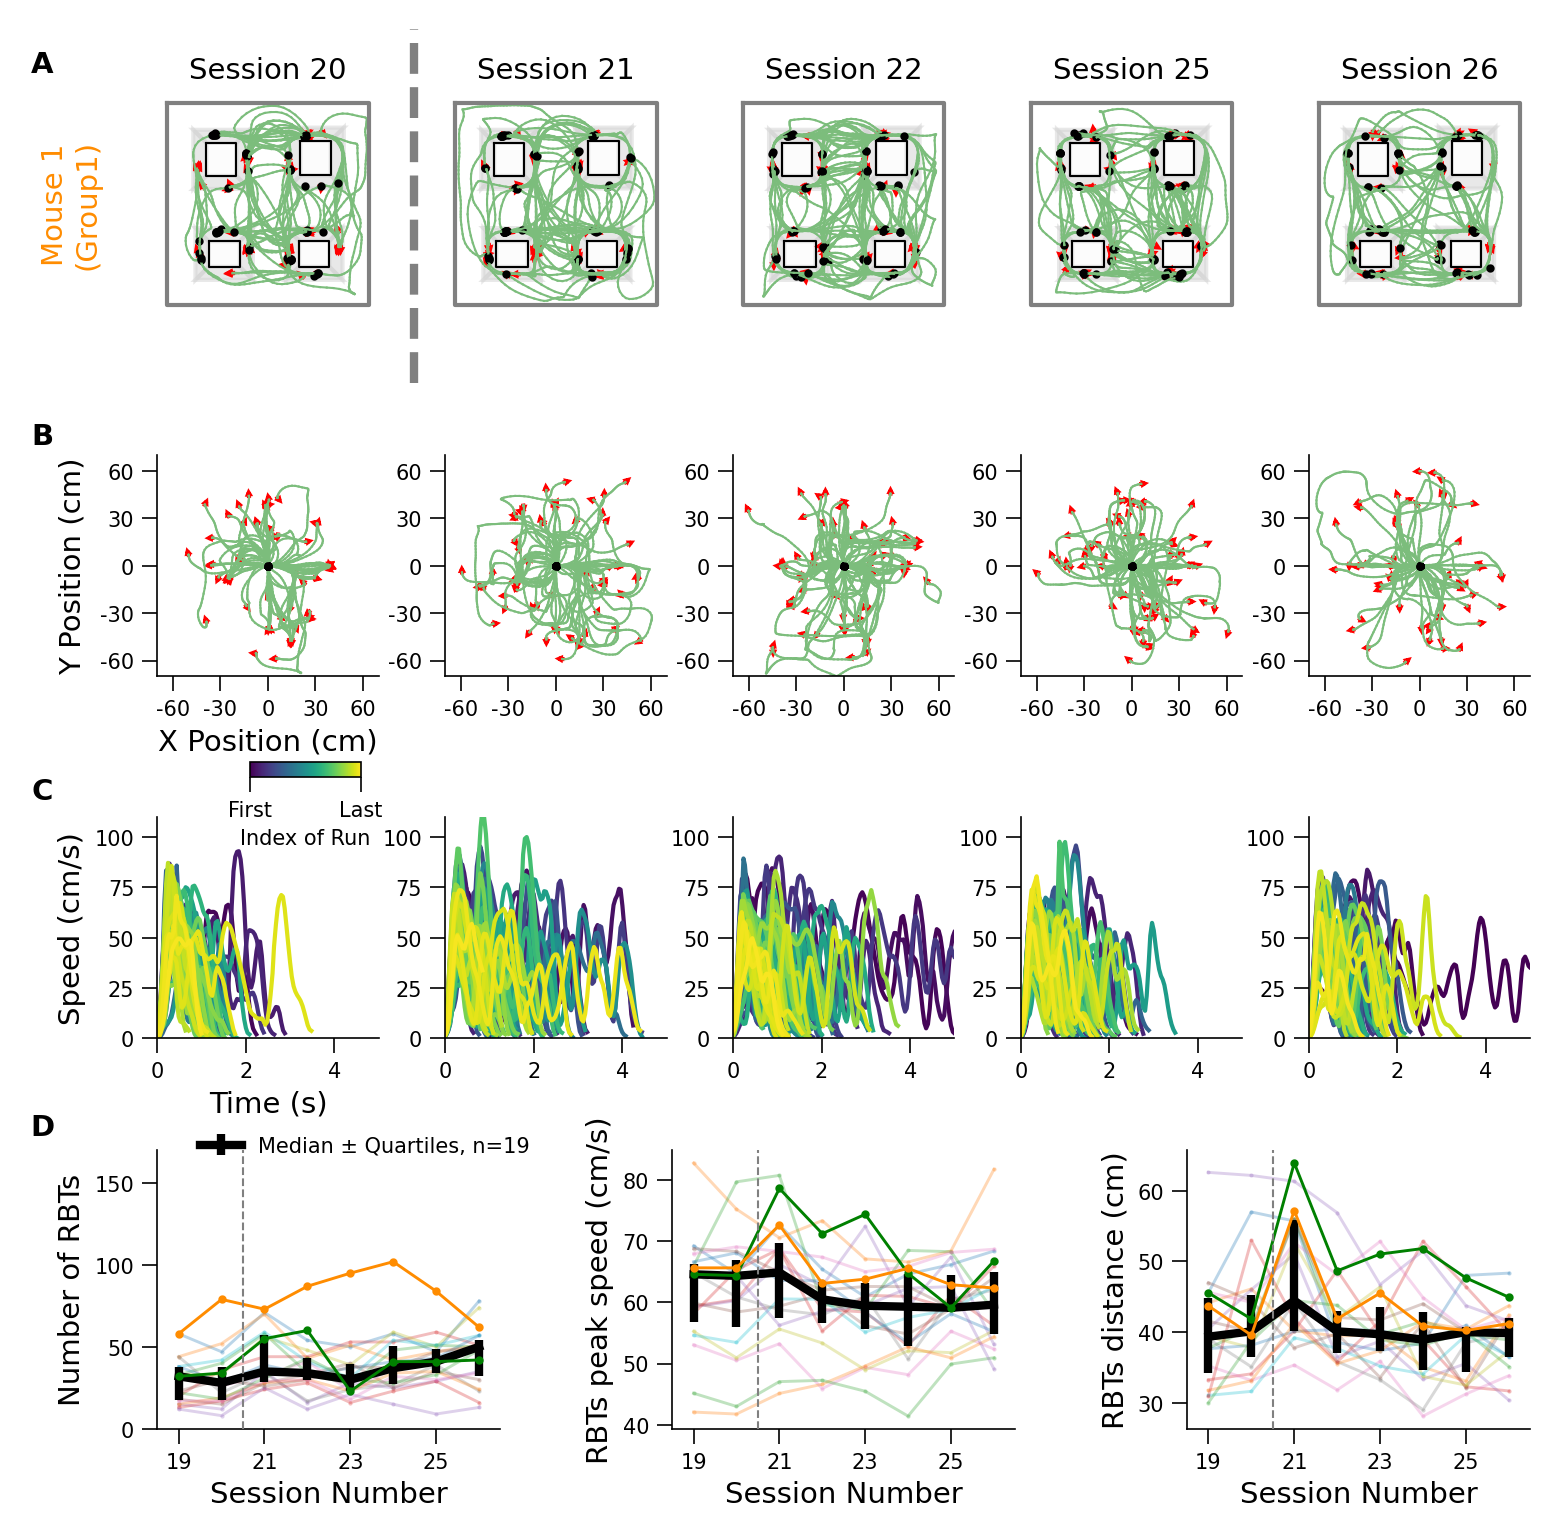

In [ ]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS17.png")
display(img)

# 1. Imports necessary libraries and functions

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
import warnings 
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [18,26]
# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset = first_and_last_session_indexes[0]

All mice folders are present in data folder.
 19 mice will be analysed



In [5]:
# Chose mice that will highlighted in statistics
illustration_mice = ['MOUEml1_8', 'MOUEml1_5']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]

# 3. Select sessions to be analysed

In [6]:
# Mouse from which data will be used to generate the plot 
example_mouse_index = 0
example_mouse = illustration_mice[example_mouse_index]

# Chosing index of the sessions to show as examples. They are chosen by their index in the list of sessions selected with start_session_index and end_session_index
illustration_sessions_indexes = [19,20,21,24,25]

# Define the arena corners coordinates
arena_coordinates_cm = [[4.5, 88.86], [90.3, 88.86], [90.3, 2.7], [4.5, 2.7]]

# 4. General of functions

In [7]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)


In [8]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    Returns:
        float: value converted in inches

    """

    return value/2.54

# 5. Panel A

In [9]:
# Setting the path to the example mouse's data folder
folder_path_example_mouse_to_analyse=os.path.join(path_to_data_folder,example_mouse)


In [10]:
def plot_run_between_towers(folder_path_mouse_to_analyse, session_index, arena_coordinates, ax, q=4, time_start=None, time_end=None, start_session_index=0):
    
    """
    Plots trajectories of the selected run types.
    
    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        arena_coordinates (list): List of four 2D coordinates, locating the corners of the arena.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        q (int, optional): Number of points used to determine movement direction to plot arrows. Default is 4.
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
        start_session_index (int, optional): Index of the first session of the list, with respect to the total number of available sessions.
                                             This should be the same value as the global variable start_session_index.
        
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time data for the trajectory
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed X and Y positions of the mouse
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Extract epoch data and trapeze coordinates
    all_epochs = session_data['all_epochs']
    all_trapezes_coordinates_cm = session_data['all_trapezes_coordinates_cm']
    
    # Retrieve the epochs corresponding to the provided runtype
    run_between_towers = all_epochs.get('run_between_towers')
    
    # Plot each square and trapeze using the same color for each tower
    fill_colors = ['lightgray'] * 4  # Use a list of light blue colors for trapezes
    
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates_cm.items()):
        for j, (trapeze, coordinates) in enumerate(trapezes.items()):
            # Close the trapeze polygon by appending the first vertex
            coordinates_copy = coordinates + [coordinates[0]]
            x_coords, y_coords = zip(*coordinates_copy)
            
            # Fill the trapeze area with the color
            ax.fill(x_coords, y_coords, color=fill_colors[j % len(fill_colors)], alpha=0.5)

    # Loop through each epoch in the runtype and plot the trajectory
    for run_between_towers in run_between_towers:
        # Get the start and end indices of the current epoch
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]

        # Skip the epoch if it is outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Check that the start and end indices are within the bounds of the trajectory time array
        if start_index < 0 or end_index >= len(traject_time):
            print(f"Indexes out of bounds")
            continue

        # Extract the positions for the current epoch
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        
        numberofpositions = len(runtype_epoch_Xpositions)

        # Ensure that the lengths of X and Y positions match
        if len(runtype_epoch_Xpositions) != len(runtype_epoch_Ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")
        
        # Define color of trajectory
        color = '#7CBD7C'
        
        # Loop through the positions to plot the trajectory
        for index in range(numberofpositions - 2):
            # Plot the line segment between consecutive positions
            ax.plot(runtype_epoch_Xpositions[index:index + 2], runtype_epoch_Ypositions[index:index + 2], color=color, linewidth=0.5)
                
        # Plot the start point as a small black circle
        ax.plot(runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0], color='black', marker='o', markersize=1)

        # Compute the direction of the arrow using the last 'q' positions (default is 4)
        if len(runtype_epoch_Xpositions) >= q:
            dx = runtype_epoch_Xpositions[-1] - runtype_epoch_Xpositions[-q]
            dy = runtype_epoch_Ypositions[-1] - runtype_epoch_Ypositions[-q]
            
            # Normalize the direction vector
            norm = np.hypot(dx, dy)
            if norm != 0:
                dx /= norm
                dy /= norm
            
            # Plot the direction arrow at the end point
            ax.arrow(runtype_epoch_Xpositions[-1], runtype_epoch_Ypositions[-1], dx, dy,
                      head_width=1, head_length=1, fc='red', ec='red')
        
    tower_coordinates = session_data['towers_coordinates_cm']

    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, 'black', alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)
            
    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)
    
    # Hide the spines (axes) from the plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove the ticks from the x and y axes
    ax.set_xticks([])
    ax.set_yticks([])


In [11]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.1, hspace=.1)
    
    # Iterate on illustrative sessions
    for j in range(len(illustration_sessions_indexes)):

        ax_1 = plt.subplot(row1[j], aspect="equal")
        
        # Plot the run between towers of the illustrative sessions
        plot_run_between_towers(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax_1, q=4)
        
        # Show the name of the illustrative sessions
        ax_1.text(0.5, 1.1, f'Session {illustration_sessions_indexes[j]+1}', va='center', ha='center', transform=ax_1.transAxes, fontsize=7)

        if j==1:
            ax_1 = plt.subplot(row1[0], aspect="equal")
            
    plt.show()

# 6. Panel B

In [12]:
def plot_runs_between_towers_origin(folder_path_mouse_to_analyse, session_index, ax, start_session_index=0, q = 4, time_start = None, time_end = None, show_legend = True, xlim = None, ylim = None, show_xlabel = True, show_ylabel = True):
    """
    Plots the runs between towers with a fixed origin for a given session.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        q (int, optional): Number of points to use for calculating the direction arrow (default is 4).
        time_start (float, optional): Start time for the plot (default is the first time point).
        time_end (float, optional): End time for the plot (default is the last time point).
        show_legend (bool, optional): Whether to show the legend (default is True).
        xlim (tuple, optional): X-axis limits for the plot.
        ylim (tuple, optional): Y-axis limits for the plot.
        show_xlabel (bool, optional): Whether to show the x-axis label (default is True).
        show_ylabel (bool, optional): Whether to show the y-axis label (default is True).
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Construct the path to the output pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time of frames from the session data
    traject_time = session_data['timeofframes']

    # Set default values for time_start and time_end if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract smoothed positions from the session data
    smoothed_positions = session_data['positions']
    smoothed_Xpositions = smoothed_positions[0]
    smoothed_Ypositions = smoothed_positions[1]

    # Copy the runs between towers data
    runs_around_tower = copy.deepcopy(session_data['all_epochs']['run_between_towers'])

    # Define a fixed origin point
    fixed_origin = (0, 0)
    labels_displayed = set()

    # Plot each run around the tower
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip runs that are outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the X and Y positions for the current run
        runtype_epoch_Xpositions = smoothed_Xpositions[start_index:end_index + 1]
        runtype_epoch_Ypositions = smoothed_Ypositions[start_index:end_index + 1]
        numberofpositions = len(runtype_epoch_Xpositions)

        # Translate the positions to the fixed origin
        start_x, start_y = runtype_epoch_Xpositions[0], runtype_epoch_Ypositions[0]
        translated_Xpositions = [x - start_x + fixed_origin[0] for x in runtype_epoch_Xpositions]
        translated_Ypositions = [y - start_y + fixed_origin[1] for y in runtype_epoch_Ypositions]

        # Define the color for the plot
        color = '#7CBD7C'

        # Plot the positions with lines connecting them
        for i in range(numberofpositions - 1):
            if i == 0:
                line_label = 'Good turns'
                labels_displayed.add('violet')
            else:
                line_label = ''

            ax.plot(translated_Xpositions[i:i+2], translated_Ypositions[i:i+2], color=color, linewidth=0.5, label=line_label)

        # Plot the starting position with a marker
        ax.plot(translated_Xpositions[0], translated_Ypositions[0], marker='o', color='black', linewidth=0.5, markersize=1)

        # Plot an arrow indicating the direction of the last segment
        if len(translated_Xpositions) >= q:
            dx = translated_Xpositions[-1] - translated_Xpositions[-q]
            dy = translated_Ypositions[-1] - translated_Ypositions[-q]
            norm_speed = np.hypot(dx, dy)
            if norm_speed != 0:
                dx /= norm_speed
                dy /= norm_speed
            ax.arrow(translated_Xpositions[-1], translated_Ypositions[-1], dx, dy,
                     head_width=1, head_length=1, fc='red', ec='red')

    # Set the x-axis label if show_xlabel is True
    if show_xlabel:
        ax.set_xlabel('X Position (cm)')

    # Set the y-axis label if show_ylabel is True
    if show_ylabel:
        ax.set_ylabel('Y Position (cm)')

    # Set the x and y axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Show the legend if show_legend is True
    if show_legend:
        ax.legend(loc=[0.4, 1.2], frameon=False)


In [13]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row2 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
    
    # Iterate on illustrative sessions
    for k in range(len(illustration_sessions_indexes)):

        ax_2 = plt.subplot(row2[k], aspect="equal")
        
        # Plot the realigned run between towers of the illustrative sessions
        plot_runs_between_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax_2, q=4, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= False, xlim=(-70,70), ylim=(-70,70))
        # Set the x and y ticks
        ax_2.set_xticks([-60,-40,-20, 0, 20, 40, 60])
        ax_2.set_yticks([-60,-40,-20, 0, 20, 40, 60])

    plt.show()

# 7. Panel C

In [14]:
def plot_runs_between_speed_profiles(folder_path_mouse_to_analyse, session_index, ax, time_start = None, time_end = None, start_session_index = 0, xlim = None, ylim = None, show_xlabel = True, show_ylabel = True, show_color_bar = True, colorbar_position=[0.25, 1, 0.5, 0.07]):
    """
    Plots the speed profiles of runs between towers for a given session.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        time_start (float, optional): Start time for the plot (default is the first time point).
        time_end (float, optional): End time for the plot (default is the last time point).
        start_session_index (int, optional): Index of the first session of the list, with respect to the total number of available sessions.
                                             This should be the same value as the global variable start_session_index.
        xlim (tuple, optional): X-axis limits for the plot.
        ylim (tuple, optional): Y-axis limits for the plot.
        show_xlabel (bool, optional): Whether to show the x-axis label (default is True).
        show_ylabel (bool, optional): Whether to show the y-axis label (default is True).
        show_color_bar (bool, optional): Whether to show the color bar (default is True).
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Construct the path to the output pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time of frames from the session data
    traject_time = session_data['timeofframes']

    # Set default values for time_start and time_end if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract speeds from the session data
    speeds = session_data['speeds']

    # Copy the runs between towers data
    runs_between_towers = copy.deepcopy(session_data['all_epochs']['run_between_towers'])

    # Initialize the total number of runs
    n_total = 0

    # Count the number of valid runs within the specified time range
    for run_between_towers in runs_between_towers:
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        n_total += 1

    # Define the colormap and normalization for the color bar
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=n_total)

    # Initialize the local index for color mapping
    local_index = 0

    # Plot each run between towers
    for run_between_towers in runs_between_towers:
        start_index, end_index = run_between_towers[0][0], run_between_towers[0][1]
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Adjust the time for the current run
        adjusted_time = [t - traject_time[start_index] for t in traject_time[start_index:end_index + 1]]

        # Plot the speed profile for the current run
        ax.plot(adjusted_time, speeds[start_index:end_index + 1], color=cmap(norm(local_index)))
        local_index += 1

    # Set the x-axis label if show_xlabel is True
    if show_xlabel:
        ax.set_xlabel('Time (s)')

    # Set the y-axis label if show_ylabel is True
    if show_ylabel:
        ax.set_ylabel('Speed (cm/s)')

    # Set the x and y axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Show the color bar if show_color_bar is True
    if show_color_bar:
        cbax = ax.inset_axes(colorbar_position)
        cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbax, orientation='horizontal')
        cbar.set_label('Index of Run', fontsize=5)
        cbar.set_ticks([0, n_total])
        cbar.set_ticklabels(['First', 'Last'], fontsize=5)


In [15]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(23)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row3 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
    
    # Iterate on illustrative sessions
    for l in range(len(illustration_sessions_indexes)):

        ax_3 = plt.subplot(row3[l], aspect="equal")
        
        # Plot the speed time profiles of the illustrative sessions
        plot_runs_between_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax_3, xlim=(0,4), ylim=(0,100), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False)
        # Set the plot shape to square
        force_aspect(ax_3,ratio=1)

    plt.show()

# 8. Panel D

In [16]:
def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], highlight_colors=['darkorange','green'], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, legend_loc=(0.05, 0.7), show_legend=True):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(np.array(session_indices)+index_offset, values, color=highlight_colors[color_idx], marker='o', linewidth=0.7, 
                        markersize=1, label=mice_to_highlight_labels[mice_to_highlight.index(mouse)], zorder=100*len(median_color))
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:
        ax.legend(frameon=False, loc=legend_loc)


In [17]:
# def compute_traj_length(traj):

#     x_diff = np.diff(traj[0])
#     y_diff = np.diff(traj[1])

#     traj_length = np.sum(np.sqrt(x_diff**2 + y_diff**2))

#     return traj_length

# def compute_straightness(traj):

#     straight_traj_x_diff = traj[0][-1] - traj[0][0]
#     straight_traj_y_diff = traj[1][-1] - traj[1][0]
    
#     straight_traj_length = np.sum(np.sqrt(straight_traj_x_diff**2 + straight_traj_y_diff**2))

#     traj_length = compute_traj_length(traj)

#     straightness = straight_traj_length/traj_length

#     return straightness

# def compute_session_rbts_straightness(folder_path_mouse_to_analyse, session_index, start_session_index=0):

#     # Get all session folders that start with 'MOU' and sort them
#     sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
#                                   if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
#                                   and name.startswith('MOU')])

#     session_to_analyse = sessions_to_analyse[start_session_index+session_index]

#     # Construct the path to the output pickle file
#     output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
#     output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

#     # Load the session data from the pickle file
#     with open(output_pickle_filepath, 'rb') as file:
#         session_data = pickle.load(file)

#     # Extract smoothed positions from the session data
#     smoothed_positions = session_data['positions']
#     smoothed_Xpositions = smoothed_positions[0]
#     smoothed_Ypositions = smoothed_positions[1]

#     straightness_list = []
    
#     for run_around_tower in session_data['all_epochs']['run_between_towers']:

#         start_idx, end_idx = run_around_tower[0][0], run_around_tower[0][1]
        
#         run_x_coords = smoothed_Xpositions[start_idx:end_idx]
#         run_y_coords = smoothed_Ypositions[start_idx:end_idx]

#         straightness = compute_straightness([run_x_coords,run_y_coords])

#         straightness_list.append(straightness)

#     return np.median(straightness_list)
    

### This cell computes and store metrics that will be plotted for each mouse across sessions. Those metrics are:
- The number of runs between towers
- The median of runs between towers maximum speed

In [18]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_maximum_run_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_run_distance_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_total_runs_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_straightness_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)
    
    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])
    
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for session_index,session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        session_traj_df, session_runs_df, session_param_df=load_data(folder_path_mouse_to_process,session_to_process)

        # Define the pickle file path
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)
        
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exists for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run between towers results from the session data
        runs_between_towers = session_data['all_epochs']['run_between_towers']

        # Compute the total number of runs between towers
        TotalRuns = len(runs_between_towers)        
        
        # Initialize lists to store runs speeds
        runs_max_speed = []
        runs_distance = []

        # Iterate through each run between towers
        for n in range(TotalRuns):   
            run = runs_between_towers[n]
            
            # Append metric in the list
            runs_max_speed.append(run[3]["maxspeed"])
            runs_distance.append(run[3]["distance"])

        ##############
        # median_straightness = compute_session_rbts_straightness(folder_path_mouse_to_process, session_index, start_session_index=session_index_offset)
        ##############
        
        # Append session data to the respective dictionaries
        mouse_maximum_run_speed_persession[mouse].append([session_index+1,np.median(runs_max_speed)])
        mouse_median_run_distance_persession[mouse].append([session_index+1,np.median(runs_distance)])
        mouse_total_runs_persession[mouse].append([session_index+1,TotalRuns])
        ##########
        # mouse_median_straightness_persession[mouse].append([session_index+1,median_straightness])
        ##########


Mouse MOUEml1_5. There is/are 8 sessions:
['MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529', 'MOUEml1_5_20230501-1038', 'MOUEml1_5_20230501-1601', 'MOUEml1_5_20230502-1133', 'MOUEml1_5_20230502-1645', 'MOUEml1_5_20230503-1032', 'MOUEml1_5_20230503-1722'] 

Mouse MOUEml1_8. There is/are 8 sessions:
['MOUEml1_8_20230430-1116', 'MOUEml1_8_20230430-1621', 'MOUEml1_8_20230501-1129', 'MOUEml1_8_20230501-1651', 'MOUEml1_8_20230502-1227', 'MOUEml1_8_20230502-1740', 'MOUEml1_8_20230503-1125', 'MOUEml1_8_20230503-1812'] 

Mouse MOUEml1_11. There is/are 8 sessions:
['MOUEml1_11_20230430-1213', 'MOUEml1_11_20230430-1724', 'MOUEml1_11_20230501-1223', 'MOUEml1_11_20230501-1753', 'MOUEml1_11_20230502-1326', 'MOUEml1_11_20230502-1842', 'MOUEml1_11_20230503-1228', 'MOUEml1_11_20230503-1909'] 

Mouse MOUEml1_12. There is/are 8 sessions:
['MOUEml1_12_20230430-1228', 'MOUEml1_12_20230430-1738', 'MOUEml1_12_20230501-1238', 'MOUEml1_12_20230501-1808', 'MOUEml1_12_20230502-1340', 'MOUEml1_12_20230502-185

In [19]:
if plotintermediatesteps:
    fig = plt.figure(figsize=(cm2inch(18), cm2inch(6)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row4 = gs[0].subgridspec(1, 3, wspace=.3, hspace=.3)
    ax_41 = plt.subplot(row4[0])
    ax_42 = plt.subplot(row4[1])
    ax_43 = plt.subplot(row4[2])

    # Plot the number of runs and median maximum speed of the runs between towers
    plot_learning_curves(mouse_total_runs_persession, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ax=ax_41, index_offset=session_index_offset, xlim=xlim_stats, show_xlabel = True, ylabel='Number of runs', tick_interval=2, show_legend=True)
    plot_learning_curves(mouse_maximum_run_speed_persession, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ax=ax_42, index_offset=session_index_offset, xlim=xlim_stats, show_xlabel = True, ylabel='Median of runs between towers \n maximum speed (cm/s)', tick_interval=2, show_legend=False)
    plot_learning_curves(mouse_median_run_distance_persession, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ax=ax_43, index_offset=session_index_offset, xlim=xlim_stats, show_xlabel = True, ylabel='Median runs distance (cm)', tick_interval=2, show_legend=False)

    plt.show()

# 9. Whole figure 

/tmp/ipykernel_15722/2255431057.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


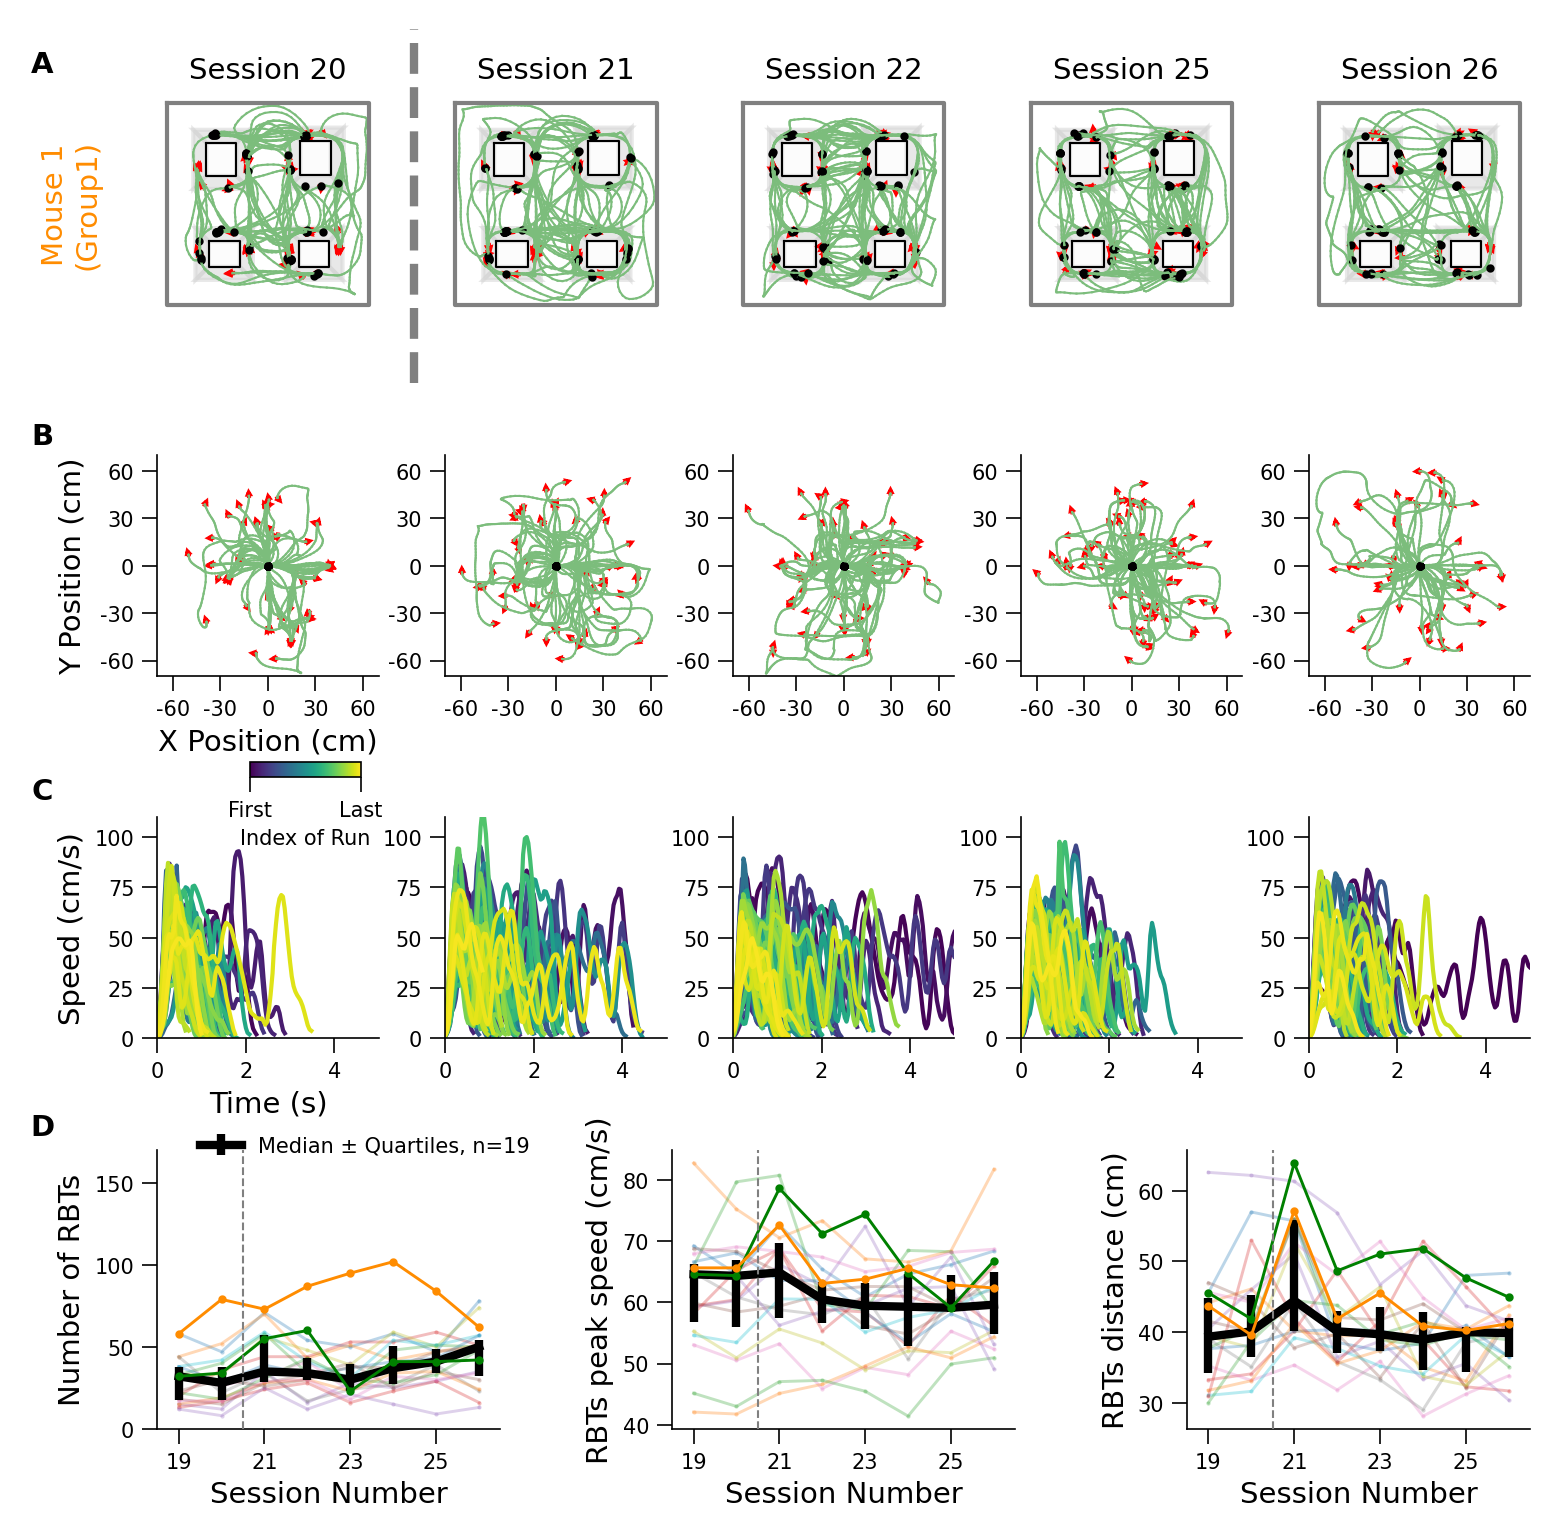

In [ ]:
switch_occurence = 20.5

fig = plt.figure(figsize=(cm2inch(15), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(4, 1 , hspace=0.3)

axes_to_align = []

### Panel A ###

row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3)
    
# Iterate on illustrative sessions
for j in range(len(illustration_sessions_indexes)):

    ax_1 = plt.subplot(row1[j], aspect="equal")
    
    if j==0:
        ax_1.text(-0.39, 0.5, f'Mouse {example_mouse_index+1}\n(Group1)', color=illustration_colors[example_mouse_index],rotation=90, va='center', ha='center', transform=ax_1.transAxes, fontsize=7)

    # Plot the run between towers of the illustrative sessions
    plot_run_between_towers(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax_1, q=4)
        
    # Show the name of the illustrative sessions
    ax_1.text(0.5, 1.1, f'Session {illustration_sessions_indexes[j]+1}', va='center', ha='center', transform=ax_1.transAxes, fontsize=7)

    if j==1:
        ax_1 = plt.subplot(row1[0], aspect="equal")
   
fig.text(.06, 0.88, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

row2 = gs[1].subgridspec(1, len(illustration_sessions_indexes), wspace=.3)
    
# Iterate on illustrative sessions
for k in range(len(illustration_sessions_indexes)):

    ax_2 = plt.subplot(row2[k], aspect="equal")
        
    # Plot the realigned run between towers of the illustrative sessions
    plot_runs_between_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax_2, q=4, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= False, xlim=(-70,70), ylim=(-70,70))
    # Set the x and y ticks
    ax_2.set_xticks([-60,-30, 0, 30, 60])
    ax_2.set_yticks([-60,-30, 0, 30, 60])

    if k==0:
        axes_to_align.append(ax_2)

fig.text(.06, 0.67, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C ###

row3 = gs[2].subgridspec(1, len(illustration_sessions_indexes), wspace=.3)
    
# Iterate on illustrative sessions
for l in range(len(illustration_sessions_indexes)):

    ax_3 = plt.subplot(row3[l], aspect="equal")
        
    # Plot the speed time profiles of the illustrative sessions
    plot_runs_between_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax_3, xlim=(0,5), ylim=(0,110), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False, colorbar_position=[0.42, 1.18, 0.5, 0.07])
    # Set the plot shape to square
    force_aspect(ax_3,ratio=1)

    if l==0:
        axes_to_align.append(ax_3)

fig.text(.06, 0.47, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###

row4 = gs[3].subgridspec(1, 3, wspace=.5)
ax_41 = plt.subplot(row4[0])
ax_42 = plt.subplot(row4[1])
ax_43 = plt.subplot(row4[2])

plot_learning_curves(mouse_total_runs_persession, index_offset=session_index_offset, mice_to_highlight=illustration_mice, ax=ax_41,ylim= (0, 170) ,xlim=xlim_stats, show_xlabel = True, ylabel='Number of RBTs', tick_interval=2, show_legend=True, legend_loc=(0.1, 0.95))
plot_learning_curves(mouse_maximum_run_speed_persession, index_offset=session_index_offset, mice_to_highlight=illustration_mice, ax=ax_42, xlim=xlim_stats, show_xlabel = True, ylabel='RBTs peak speed (cm/s)', tick_interval=2, show_legend=False)
plot_learning_curves(mouse_median_run_distance_persession, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ax=ax_43, index_offset=session_index_offset, xlim=xlim_stats, show_xlabel = True, ylabel='RBTs distance (cm)', tick_interval=2, show_legend=False)

if switch_occurence:

    ax_41.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, label="Protocol change", zorder=2000)
    ax_42.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, label="Protocol change", zorder=2000)
    ax_43.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, label="Protocol change", zorder=2000)


fig.text(.06, 0.28, 'D', weight='bold', va='center', ha='center', fontsize=7)

axes_to_align.append(ax_43)

fig.align_ylabels(axes_to_align)

x_fig = 0.27      # horizontal position (from 0 to 1 across the figure)
y0 = 0.7       # bottom of the line (figure coordinate)
y1 = 0.9        # top of the line (figure coordinate)

line = plt.Line2D([x_fig, x_fig], [y0, y1], transform=fig.transFigure,
                  color='grey', linewidth=2,linestyle='--')
    
fig.add_artist(line)

fig.tight_layout()
plt.savefig("FigureS17.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)



In [ ]:
# Save the figure as a PDF
fig.savefig("FigureS17.pdf", format="pdf", bbox_inches='tight', dpi=300)
